In [50]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

In [51]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [52]:
query = """
SELECT  t.uid,
        t.labname,
        t.first_commit_ts,
        d.deadlines  AS deadline_ts
FROM    test   AS t                       
JOIN    deadlines d ON d.labs = t.labname
WHERE   t.labname <> 'project1'         
"""
test_raw = pd.read_sql(query, conn)
test_raw['first_commit_ts'] = pd.to_datetime(test_raw['first_commit_ts'])
test_raw['deadline']        = pd.to_datetime(test_raw['deadline_ts'], unit='s')

test_raw['diff_h'] = (
    (test_raw['first_commit_ts'] - test_raw['deadline'])
      .dt.total_seconds() / 3600
)
lag_df = (
    test_raw
      .groupby('uid', as_index=False)
      .agg(avg_diff=('diff_h', 'mean'))
)

In [53]:
pageviews = pd.read_sql("""
        SELECT  p.uid,
                COUNT(*) AS pageviews
        FROM    pageviews  AS p
        JOIN    test       AS t  ON t.uid = p.uid  
        WHERE   labname <> 'project1'
        GROUP BY p.uid;
""", conn)

commits = pd.read_sql("""
    SELECT uid, COUNT(*) AS num_commits
    FROM   checker
    WHERE  uid IN (SELECT uid FROM test)
      AND  labname <> 'project1'
      AND  status = 'ready'
      AND  numTrials = 1
    GROUP  BY uid
""", conn)

df = (
    lag_df
      .merge(pageviews, on='uid', how='left')
      .merge(commits,   on='uid', how='left')
      .fillna(0)      
) # Объединение всех данных

## Построение матрицы рассеяния


array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='num_commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='num_commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='num_commits'>,
        <Axes: xlabel='pageviews', ylabel='num_commits'>,
        <Axes: xlabel='num_commits', ylabel='num_commits'>]], dtype=object)

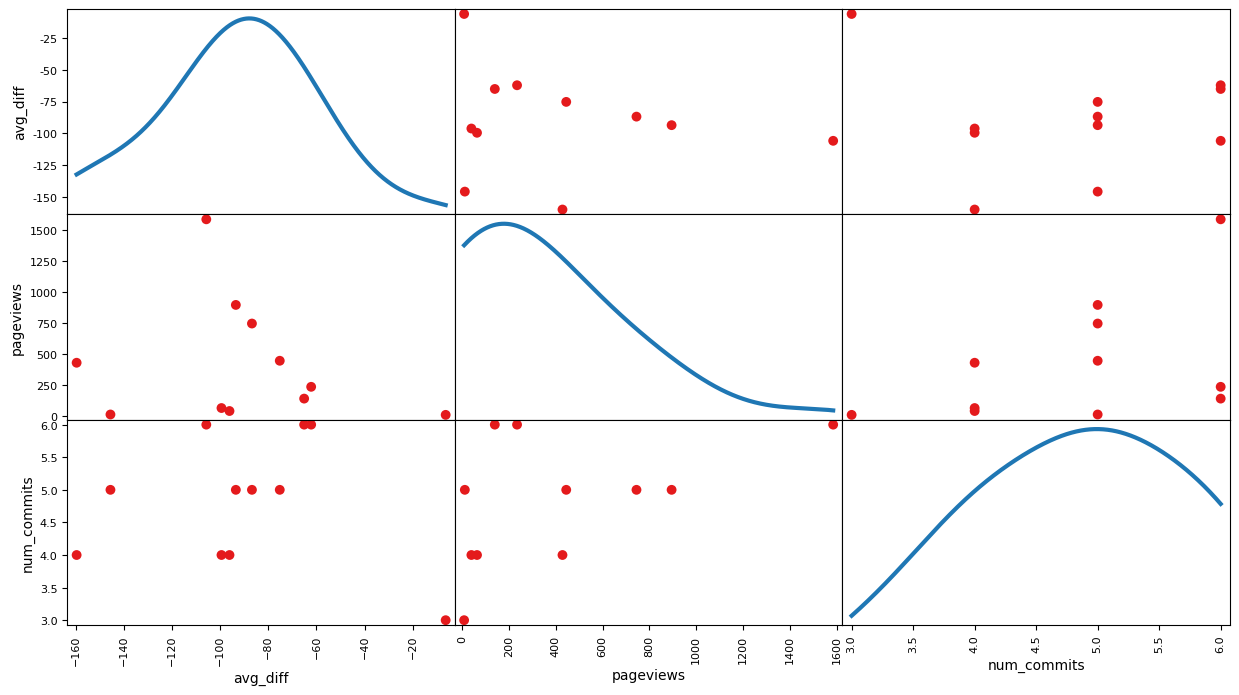

In [ ]:
pd.plotting.scatter_matrix(
    df[['avg_diff', 'pageviews', 'num_commits']],
    figsize=(15, 8),
    alpha=1.0,
    s=200,                
    diagonal='kde',
    density_kwds={'linewidth': 3}, 
    hist_kwds=None,  
    color='#e41a1c',
    grid=True
)

In [55]:
conn.close()

Можно ли сказать, что если у пользователя мало просмотров страниц, то, скорее всего, у него мало и коммитов? - нет.
Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, скорее всего, небольшая средняя разница между первым коммитом и крайним сроком выполнения лабораторных работ?- нет.
Можем ли мы сказать, что есть много пользователей с малым количеством коммитов и несколько с большим количеством коммитов? - да.
Можно ли сказать, что есть много пользователей с небольшой средней разницей и несколько с большой средней разницей? - нет.